# DoWhy Tutorial 12: Mediation, Direct, And Indirect Effects

Most causal analyses ask whether a treatment changes an outcome. Mediation analysis asks a more diagnostic question: **how much of the treatment effect travels through a specific intermediate variable?**

This notebook uses DoWhy to decompose an effect into:

- **Total effect:** the overall effect of the treatment on the outcome.
- **Natural indirect effect:** the part that flows through a mediator.
- **Natural direct effect:** the remaining part that does not flow through that mediator.
- **Controlled direct effect:** the effect of the treatment when the mediator is held fixed at a chosen value.

The example is intentionally small and synthetic so the true structural decomposition is known. That makes it easier to see what DoWhy is estimating and where the assumptions enter.

## Learning Goals

By the end of this notebook, you should be able to:

- Distinguish total, direct, indirect, and controlled direct effects.
- Build a causal graph that explicitly marks a mediator.
- Identify total, natural indirect, and natural direct estimands with DoWhy.
- Estimate mediation effects with `mediation.two_stage_regression`.
- Reproduce the same decomposition manually with two regressions.
- Explain why controlling for a mediator is correct for direct-effect questions but wrong for total-effect questions.
- Report mediation results with the assumptions and limitations attached.

## Why Mediation Is Subtle

Mediation is tempting because it turns one causal effect into a story about pathways. That story can be useful, but it is also assumption-heavy.

For a treatment `A`, mediator `M`, outcome `Y`, and observed pre-treatment covariates `X`, mediation asks questions like:

- How much does `A` change `M`?
- How much does `M` change `Y`, after accounting for `A` and pre-treatment covariates?
- Does `A` still affect `Y` after holding the mediator pathway fixed?

The most common mistake is to treat mediation as a purely predictive exercise. It is not. The mediator is post-treatment, so including or excluding it changes the estimand. The notebook keeps that distinction visible throughout.

## Setup

This cell imports the libraries, configures plotting, creates output folders, and suppresses known noisy warnings. The code also imports `EstimandType`, which lets us ask DoWhy for total, natural indirect, and natural direct estimands explicitly.

In [1]:
from pathlib import Path
import os
import warnings

# Keep Matplotlib cache files in a writable location during notebook execution.
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-ranking-sys")

warnings.filterwarnings("default")
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=PendingDeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*IProgress not found.*")
warnings.filterwarnings("ignore", message=".*setParseAction.*deprecated.*")
warnings.filterwarnings("ignore", message=".*copy keyword is deprecated.*")
warnings.filterwarnings("ignore", message=".*variables are assumed unobserved.*")
warnings.filterwarnings("ignore", module="dowhy.causal_estimators.regression_estimator")
warnings.filterwarnings("ignore", module="pydot.dot_parser")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import statsmodels.api as sm

from IPython.display import display
from dowhy import CausalModel
from dowhy.causal_identifier import EstimandType
import dowhy

RANDOM_SEED = 2026
rng = np.random.default_rng(RANDOM_SEED)

OUTPUT_DIR = Path("outputs")
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

print(f"DoWhy version: {getattr(dowhy, '__version__', 'unknown')}")
print(f"Figures will be saved to: {FIGURE_DIR.resolve()}")
print(f"Tables will be saved to: {TABLE_DIR.resolve()}")

DoWhy version: 0.14
Figures will be saved to: /home/apex/Documents/ranking_sys/notebooks/tutorials/dowhy/outputs/figures
Tables will be saved to: /home/apex/Documents/ranking_sys/notebooks/tutorials/dowhy/outputs/tables


The environment is ready once the DoWhy version and output folders print. Every saved table and figure in this notebook uses an `12_` prefix.

## Mediation Vocabulary

The next table defines the core estimands in plain language. Keeping this vocabulary explicit helps prevent one of the most common reporting errors: calling a direct-effect model a total-effect model.

In [2]:
mediation_vocabulary = pd.DataFrame(
    [
        {
            "estimand": "Total effect",
            "symbolic idea": "Y(A=1) - Y(A=0)",
            "plain meaning": "Overall change in the outcome when the treatment changes.",
            "mediator handling": "The mediator is allowed to change naturally after treatment changes.",
        },
        {
            "estimand": "Natural indirect effect",
            "symbolic idea": "Effect through A -> M -> Y",
            "plain meaning": "Part of the effect transmitted through the mediator.",
            "mediator handling": "The mediator is changed as it would naturally change under treatment.",
        },
        {
            "estimand": "Natural direct effect",
            "symbolic idea": "Effect through paths other than A -> M -> Y",
            "plain meaning": "Part of the effect not transmitted through the chosen mediator.",
            "mediator handling": "The mediator pathway is held to its natural reference-world value.",
        },
        {
            "estimand": "Controlled direct effect",
            "symbolic idea": "Y(A=1, M=m) - Y(A=0, M=m)",
            "plain meaning": "Treatment effect if the mediator were fixed to a specific value.",
            "mediator handling": "The analyst chooses a fixed mediator value.",
        },
    ]
)

mediation_vocabulary.to_csv(TABLE_DIR / "12_mediation_vocabulary.csv", index=False)
display(mediation_vocabulary)

,estimand,symbolic idea,plain meaning,mediator handling
0,Total effect,Y(A=1) - Y(A=0),Overall change in the outcome when the treatme...,The mediator is allowed to change naturally af...
1,Natural indirect effect,Effect through A -> M -> Y,Part of the effect transmitted through the med...,The mediator is changed as it would naturally ...
2,Natural direct effect,Effect through paths other than A -> M -> Y,Part of the effect not transmitted through the...,The mediator pathway is held to its natural re...
3,Controlled direct effect,"Y(A=1, M=m) - Y(A=0, M=m)",Treatment effect if the mediator were fixed to...,The analyst chooses a fixed mediator value.


The total effect is the broad policy estimand. The direct and indirect effects are pathway estimands. The controlled direct effect is a hypothetical intervention that fixes the mediator to a selected value.

## Teaching Scenario

We will study a system with a binary exposure, one mediator, one outcome, and three observed pre-treatment covariates. The names are generic and product-like, but the pattern applies broadly.

The causal question is:

> How much of the effect of discovery exposure on future value is transmitted through satisfaction depth?

The mediator is measured after the exposure and before the outcome. That timing is essential: a mediator must sit on a directed path from treatment to outcome.

In [3]:
field_guide = pd.DataFrame(
    [
        {
            "column": "baseline_need",
            "role": "pre-treatment confounder",
            "plain meaning": "How much need or intent the unit had before exposure.",
            "causal timing": "Measured before treatment.",
        },
        {
            "column": "prior_activity",
            "role": "pre-treatment confounder",
            "plain meaning": "Historical activity before the current exposure.",
            "causal timing": "Measured before treatment.",
        },
        {
            "column": "account_tenure",
            "role": "pre-treatment confounder",
            "plain meaning": "How mature or established the account is.",
            "causal timing": "Measured before treatment.",
        },
        {
            "column": "discovery_exposure",
            "role": "binary treatment",
            "plain meaning": "Whether the unit receives a stronger discovery exposure.",
            "causal timing": "Treatment moment.",
        },
        {
            "column": "satisfaction_depth",
            "role": "mediator",
            "plain meaning": "Post-exposure satisfaction or depth of engagement.",
            "causal timing": "Measured after treatment, before outcome.",
        },
        {
            "column": "future_value",
            "role": "outcome",
            "plain meaning": "Later value measured after the mediator.",
            "causal timing": "Measured after treatment and mediator.",
        },
    ]
)

field_guide.to_csv(TABLE_DIR / "12_field_guide.csv", index=False)
display(field_guide)

,column,role,plain meaning,causal timing
0,baseline_need,pre-treatment confounder,How much need or intent the unit had before ex...,Measured before treatment.
1,prior_activity,pre-treatment confounder,Historical activity before the current exposure.,Measured before treatment.
2,account_tenure,pre-treatment confounder,How mature or established the account is.,Measured before treatment.
3,discovery_exposure,binary treatment,Whether the unit receives a stronger discovery...,Treatment moment.
4,satisfaction_depth,mediator,Post-exposure satisfaction or depth of engagem...,"Measured after treatment, before outcome."
5,future_value,outcome,Later value measured after the mediator.,Measured after treatment and mediator.


The timing column is doing real causal work. Pre-treatment covariates can be adjustment variables; the mediator is post-treatment and should not be included in a total-effect adjustment set.

## Simulate A Known Mediation System

The next cell creates data from a structural system where the true decomposition is known. Treatment affects the mediator, the mediator affects the outcome, and treatment also has a direct effect on the outcome.

The true path coefficients are:

- Treatment to mediator: `0.65`
- Mediator to outcome: `0.75`
- Direct treatment to outcome: `0.30`

So the true indirect effect is `0.65 * 0.75 = 0.4875`, and the true total effect is `0.30 + 0.4875 = 0.7875`.

In [4]:
N = 8_000

baseline_need = rng.normal(0, 1, size=N)
prior_activity = rng.normal(0, 1, size=N)
account_tenure = rng.normal(0, 1, size=N)

# Treatment assignment is confounded by pre-treatment covariates.
treatment_logit = (
    -0.15
    + 0.65 * baseline_need
    + 0.45 * prior_activity
    - 0.25 * account_tenure
)
treatment_probability = 1 / (1 + np.exp(-treatment_logit))
discovery_exposure = rng.binomial(1, treatment_probability, size=N)

# The mediator is caused by treatment and by the same pre-treatment covariates.
satisfaction_depth = (
    0.65 * discovery_exposure
    + 0.55 * baseline_need
    + 0.30 * prior_activity
    - 0.20 * account_tenure
    + rng.normal(0, 0.65, size=N)
)

# The outcome has both a direct treatment path and an indirect path through the mediator.
future_value = (
    0.30 * discovery_exposure
    + 0.75 * satisfaction_depth
    + 0.45 * baseline_need
    + 0.25 * prior_activity
    - 0.15 * account_tenure
    + rng.normal(0, 0.70, size=N)
)

mediation_df = pd.DataFrame(
    {
        "baseline_need": baseline_need,
        "prior_activity": prior_activity,
        "account_tenure": account_tenure,
        "treatment_probability": treatment_probability,
        "discovery_exposure": discovery_exposure,
        "satisfaction_depth": satisfaction_depth,
        "future_value": future_value,
    }
)

true_effects = pd.DataFrame(
    [
        {
            "quantity": "natural indirect effect",
            "true_value": 0.65 * 0.75,
            "calculation": "treatment -> mediator coefficient times mediator -> outcome coefficient",
        },
        {
            "quantity": "natural direct effect",
            "true_value": 0.30,
            "calculation": "direct treatment -> outcome coefficient",
        },
        {
            "quantity": "total effect",
            "true_value": 0.30 + 0.65 * 0.75,
            "calculation": "natural direct effect plus natural indirect effect",
        },
    ]
)

mediation_df.to_csv(TABLE_DIR / "12_teaching_dataset.csv", index=False)
true_effects.to_csv(TABLE_DIR / "12_true_effects.csv", index=False)

display(mediation_df.head())
display(true_effects)

,baseline_need,prior_activity,account_tenure,treatment_probability,discovery_exposure,satisfaction_depth,future_value
0,-0.7931,-0.1195,-1.3164,0.4037,0,-0.1000,0.1501
1,0.2406,0.4444,1.3240,0.4689,0,-0.2458,0.7898
2,-1.8963,0.1472,-0.4610,0.2313,0,0.0872,-0.3601
3,1.3958,-1.4642,-1.5277,0.6178,1,0.2714,0.3319
4,0.6383,-0.3150,1.1598,0.4584,0,1.4339,2.1481


,quantity,true_value,calculation
0,natural indirect effect,0.4875,treatment -> mediator coefficient times mediat...
1,natural direct effect,0.3000,direct treatment -> outcome coefficient
2,total effect,0.7875,natural direct effect plus natural indirect ef...


The dataset includes the treatment probability only for diagnostics. It is not needed by DoWhy's regression estimator, but it helps us show that treatment assignment is not random in the raw data.

## Basic Data Checks

Before causal modeling, check sample size, missingness, scales, and treatment rate. These checks are simple, but they catch many avoidable notebook mistakes.

In [5]:
basic_summary = (
    mediation_df.drop(columns=["treatment_probability"])
    .describe()
    .T
    .assign(missing_rate=mediation_df.drop(columns=["treatment_probability"]).isna().mean())
    .reset_index(names="column")
)

treatment_rate = mediation_df["discovery_exposure"].mean()

basic_summary.to_csv(TABLE_DIR / "12_basic_summary.csv", index=False)
print(f"Treatment rate: {treatment_rate:.3f}")
display(basic_summary)

Treatment rate: 0.466


,column,count,mean,std,min,25%,50%,75%,max,missing_rate
0,baseline_need,"8,000.0000",-0.0015,1.0090,-3.9877,-0.6982,0.0186,0.6911,3.6210,0.0000
1,prior_activity,"8,000.0000",-0.0080,0.9972,-3.6594,-0.6929,-0.0016,0.6644,3.6675,0.0000
2,account_tenure,"8,000.0000",0.0157,0.9973,-4.0446,-0.6487,0.0101,0.6816,4.0134,0.0000
3,discovery_exposure,"8,000.0000",0.4655,0.4988,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000
4,satisfaction_depth,"8,000.0000",0.3008,1.0563,-4.2183,-0.4223,0.2816,1.0357,4.1196,0.0000
5,future_value,"8,000.0000",0.3538,1.5154,-5.0133,-0.6948,0.3556,1.3799,5.5639,0.0000


The treatment rate is close to balanced, but balance in counts does not imply balance in covariates. The next section checks the confounding structure more directly.

## Treatment Assignment Diagnostics

Because treatment assignment depends on pre-treatment covariates, treated and control units should differ before adjustment. That is exactly why the total-effect and mediation models need to account for these covariates.

In [6]:
def standardized_mean_difference(data, column, treatment_col="discovery_exposure"):
    treated = data.loc[data[treatment_col] == 1, column]
    control = data.loc[data[treatment_col] == 0, column]
    pooled_sd = np.sqrt((treated.var(ddof=1) + control.var(ddof=1)) / 2)
    return (treated.mean() - control.mean()) / pooled_sd

balance_rows = []
for column in ["baseline_need", "prior_activity", "account_tenure"]:
    balance_rows.append(
        {
            "covariate": column,
            "control_mean": mediation_df.loc[mediation_df["discovery_exposure"] == 0, column].mean(),
            "treated_mean": mediation_df.loc[mediation_df["discovery_exposure"] == 1, column].mean(),
            "standardized_mean_difference": standardized_mean_difference(mediation_df, column),
        }
    )

balance_table = pd.DataFrame(balance_rows)
balance_table.to_csv(TABLE_DIR / "12_treatment_balance_table.csv", index=False)
display(balance_table)

,covariate,control_mean,treated_mean,standardized_mean_difference
0,baseline_need,-0.2730,0.3102,0.6036
1,prior_activity,-0.1875,0.1980,0.3936
2,account_tenure,0.1273,-0.1125,-0.2421


The standardized differences show visible pre-treatment imbalance. That imbalance is by design in this teaching data, and it motivates the adjustment set in the graph.

## Plot Covariate Imbalance

The plot below makes the assignment pattern easier to scan. Covariates with larger absolute standardized mean differences are more imbalanced between treated and control groups.

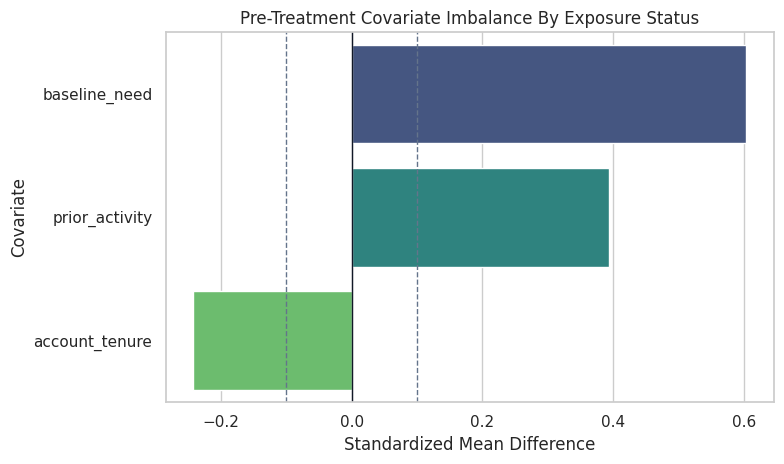

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.8))
sns.barplot(
    data=balance_table,
    x="standardized_mean_difference",
    y="covariate",
    hue="covariate",
    dodge=False,
    palette="viridis",
    legend=False,
    ax=ax,
)
ax.axvline(0, color="#111827", linewidth=1)
ax.axvline(0.1, color="#64748b", linewidth=1, linestyle="--")
ax.axvline(-0.1, color="#64748b", linewidth=1, linestyle="--")
ax.set_title("Pre-Treatment Covariate Imbalance By Exposure Status")
ax.set_xlabel("Standardized Mean Difference")
ax.set_ylabel("Covariate")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "12_covariate_imbalance.png", dpi=160, bbox_inches="tight")
plt.show()

The covariates are not balanced, so a raw difference in outcomes would mix causal effects with selection into exposure. The graph will make those adjustment variables explicit.

## Specify The Mediation Graph

The graph states three types of paths:

- Covariates affect treatment, mediator, and outcome.
- Treatment affects the mediator.
- Treatment affects the outcome directly.
- The mediator affects the outcome.

This is the structure needed to decompose the total effect into direct and indirect pathways.

In [8]:
causal_edges = [
    ("baseline_need", "discovery_exposure"),
    ("prior_activity", "discovery_exposure"),
    ("account_tenure", "discovery_exposure"),
    ("baseline_need", "satisfaction_depth"),
    ("prior_activity", "satisfaction_depth"),
    ("account_tenure", "satisfaction_depth"),
    ("baseline_need", "future_value"),
    ("prior_activity", "future_value"),
    ("account_tenure", "future_value"),
    ("discovery_exposure", "satisfaction_depth"),
    ("discovery_exposure", "future_value"),
    ("satisfaction_depth", "future_value"),
]

causal_graph = nx.DiGraph(causal_edges)
edge_table = pd.DataFrame(causal_edges, columns=["cause", "effect"])
edge_table.to_csv(TABLE_DIR / "12_mediation_graph_edges.csv", index=False)
display(edge_table)

,cause,effect
0,baseline_need,discovery_exposure
1,prior_activity,discovery_exposure
2,account_tenure,discovery_exposure
3,baseline_need,satisfaction_depth
4,prior_activity,satisfaction_depth
5,account_tenure,satisfaction_depth
6,baseline_need,future_value
7,prior_activity,future_value
8,account_tenure,future_value
9,discovery_exposure,satisfaction_depth


The mediator path is `discovery_exposure -> satisfaction_depth -> future_value`. The direct path is `discovery_exposure -> future_value`.

## Visualize The Mediation DAG

A mediation graph should make timing obvious: pre-treatment covariates first, treatment second, mediator third, outcome last. The arrows below are drawn to stop before the node boxes so the diagram remains readable.

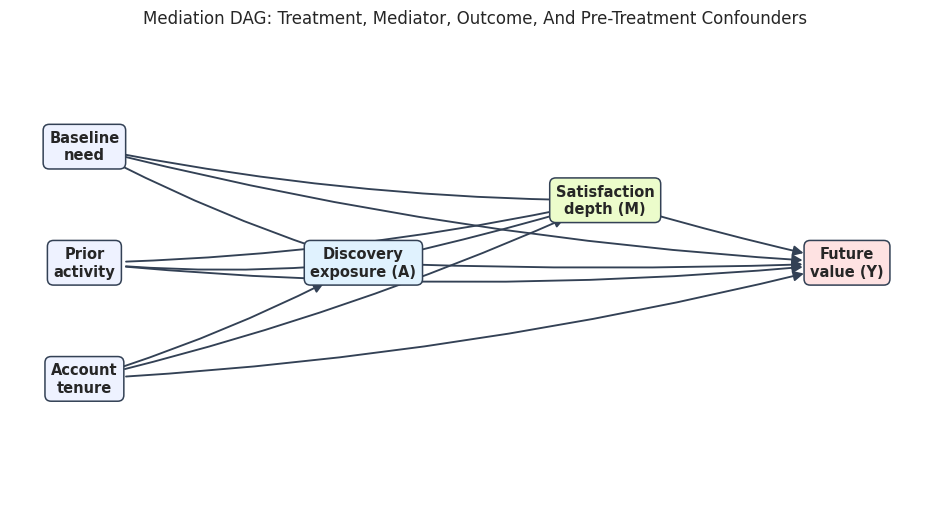

In [9]:
positions = {
    "baseline_need": (0.08, 0.78),
    "prior_activity": (0.08, 0.52),
    "account_tenure": (0.08, 0.26),
    "discovery_exposure": (0.38, 0.52),
    "satisfaction_depth": (0.64, 0.66),
    "future_value": (0.90, 0.52),
}
node_labels = {
    "baseline_need": "Baseline\nneed",
    "prior_activity": "Prior\nactivity",
    "account_tenure": "Account\ntenure",
    "discovery_exposure": "Discovery\nexposure (A)",
    "satisfaction_depth": "Satisfaction\ndepth (M)",
    "future_value": "Future\nvalue (Y)",
}
node_colors = {
    "baseline_need": "#eef2ff",
    "prior_activity": "#eef2ff",
    "account_tenure": "#eef2ff",
    "discovery_exposure": "#e0f2fe",
    "satisfaction_depth": "#ecfccb",
    "future_value": "#fee2e2",
}

fig, ax = plt.subplots(figsize=(12, 5.8))
ax.set_axis_off()

for source, target in causal_edges:
    # Slightly curve arrows from covariates to reduce overlap in the left side of the DAG.
    rad = 0.05 if source in {"baseline_need", "prior_activity", "account_tenure"} else 0.02
    ax.annotate(
        "",
        xy=positions[target],
        xytext=positions[source],
        arrowprops=dict(
            arrowstyle="-|>",
            color="#334155",
            linewidth=1.35,
            shrinkA=30,
            shrinkB=32,
            mutation_scale=15,
            connectionstyle=f"arc3,rad={rad}",
        ),
    )

for node, (x, y) in positions.items():
    ax.text(
        x,
        y,
        node_labels[node],
        ha="center",
        va="center",
        fontsize=10.5,
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.42",
            facecolor=node_colors[node],
            edgecolor="#334155",
            linewidth=1.1,
        ),
    )

ax.set_title("Mediation DAG: Treatment, Mediator, Outcome, And Pre-Treatment Confounders", pad=18)
fig.savefig(FIGURE_DIR / "12_mediation_dag.png", dpi=160, bbox_inches="tight")
plt.show()

The graph shows why the mediator is special. It is a descendant of treatment, so it should not be treated like an ordinary pre-treatment control when estimating the total effect.

## Build The DoWhy Causal Model

DoWhy needs the data, treatment name, outcome name, and graph. The graph is written as a DOT string because this is the most portable format for DoWhy's classic `CausalModel` workflow.

In [10]:
graph_dot = """
digraph {
    baseline_need -> discovery_exposure;
    prior_activity -> discovery_exposure;
    account_tenure -> discovery_exposure;

    baseline_need -> satisfaction_depth;
    prior_activity -> satisfaction_depth;
    account_tenure -> satisfaction_depth;

    baseline_need -> future_value;
    prior_activity -> future_value;
    account_tenure -> future_value;

    discovery_exposure -> satisfaction_depth;
    discovery_exposure -> future_value;
    satisfaction_depth -> future_value;
}
"""

model = CausalModel(
    data=mediation_df.drop(columns=["treatment_probability"]),
    treatment="discovery_exposure",
    outcome="future_value",
    graph=graph_dot,
)

print("CausalModel created for treatment = discovery_exposure and outcome = future_value")

CausalModel created for treatment = discovery_exposure and outcome = future_value


The model object now holds the graph and variable roles. The next step is identification: asking which causal estimands follow from the graph assumptions.

## Identify The Total Effect

The total effect lets the mediator change naturally after treatment changes. In DoWhy, this is the standard nonparametric average treatment effect estimand.

In [11]:
total_estimand = model.identify_effect(
    estimand_type=EstimandType.NONPARAMETRIC_ATE,
    proceed_when_unidentifiable=True,
)

print(total_estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
         d                                                                     ↪
────────────────────(E[future_value|baseline_need,prior_activity,account_tenur ↪
d[discoveryₑₓₚₒₛᵤᵣₑ]                                                           ↪

↪    
↪ e])
↪    
Estimand assumption 1, Unconfoundedness: If U→{discovery_exposure} and U→future_value then P(future_value|discovery_exposure,baseline_need,prior_activity,account_tenure,U) = P(future_value|discovery_exposure,baseline_need,prior_activity,account_tenure)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
         d                                                                     ↪
────────────────────(E[future_value|baseline_need,prior_activity,account_tenur ↪
d[discov

DoWhy identifies a backdoor adjustment estimand using the pre-treatment covariates. Notice that `satisfaction_depth` is not part of the total-effect adjustment set because it is a mediator.

## Estimate The Total Effect With DoWhy

The next cell estimates the total effect using linear regression adjustment. This is appropriate for the teaching data because the structural equations are linear in the treatment and mediator pathway.

In [12]:
total_effect_estimate = model.estimate_effect(
    total_estimand,
    method_name="backdoor.linear_regression",
    control_value=0,
    treatment_value=1,
    confidence_intervals=False,
)

print(f"Estimated total effect: {total_effect_estimate.value:.4f}")

Estimated total effect: 0.7986


The total-effect estimate is close to the known structural total effect. It includes both the direct path from exposure to future value and the indirect path through satisfaction depth.

## Identify The Natural Indirect Effect

The natural indirect effect asks how much of the exposure effect flows through the mediator. DoWhy exposes this as `EstimandType.NONPARAMETRIC_NIE`.

In [13]:
indirect_estimand = model.identify_effect(
    estimand_type=EstimandType.NONPARAMETRIC_NIE,
    proceed_when_unidentifiable=True,
)

print(indirect_estimand)

Estimand type: EstimandType.NONPARAMETRIC_NIE

### Estimand : 1
Estimand name: mediation
Estimand expression:
 ⎡          d                                 d                                ⎤
E⎢─────────────────────(futureᵥₐₗᵤₑ)⋅────────────────────([satisfaction_depth])⎥
 ⎣d[satisfaction_depth]              d[discoveryₑₓₚₒₛᵤᵣₑ]                      ⎦
Estimand assumption 1, Mediation: satisfaction_depth intercepts (blocks) all directed paths from discovery_exposure to f,u,t,u,r,e,_,v,a,l,u,e except the path {discovery_exposure}→{f,u,t,u,r,e,_,v,a,l,u,e}.
Estimand assumption 2, First-stage-unconfoundedness: If U→{discovery_exposure} and U→{satisfaction_depth} then P(satisfaction_depth|discovery_exposure,U) = P(satisfaction_depth|discovery_exposure)
Estimand assumption 3, Second-stage-unconfoundedness: If U→{satisfaction_depth} and U→future_value then P(future_value|satisfaction_depth, discovery_exposure, U) = P(future_value|satisfaction_depth, discovery_exposure)



The printed assumptions are stronger than the total-effect assumptions. Mediation requires assumptions for the treatment-to-mediator stage and the mediator-to-outcome stage.

## Estimate The Natural Indirect Effect With DoWhy

DoWhy's `mediation.two_stage_regression` estimator fits a first-stage model for the treatment-to-mediator relationship and a second-stage model for the mediator-to-outcome relationship, then multiplies the relevant coefficients for the indirect effect.

In [14]:
indirect_effect_estimate = model.estimate_effect(
    indirect_estimand,
    method_name="mediation.two_stage_regression",
    control_value=0,
    treatment_value=1,
    confidence_intervals=False,
)

print(f"Estimated natural indirect effect: {indirect_effect_estimate.value:.4f}")

Estimated natural indirect effect: 0.4906


The indirect effect is the pathway estimate through `satisfaction_depth`. In this teaching setup, it should be near the product of the true treatment-to-mediator and mediator-to-outcome coefficients.

## Identify The Natural Direct Effect

The natural direct effect asks for the part of the treatment effect that does not flow through the chosen mediator. DoWhy exposes this as `EstimandType.NONPARAMETRIC_NDE`.

In [15]:
direct_estimand = model.identify_effect(
    estimand_type=EstimandType.NONPARAMETRIC_NDE,
    proceed_when_unidentifiable=True,
)

print(direct_estimand)

Estimand type: EstimandType.NONPARAMETRIC_NDE

### Estimand : 1
Estimand name: mediation
Estimand expression:
 ⎡         d                                           ⎤
E⎢────────────────────(future_value|satisfaction_depth)⎥
 ⎣d[discoveryₑₓₚₒₛᵤᵣₑ]                                 ⎦
Estimand assumption 1, Mediation: satisfaction_depth intercepts (blocks) all directed paths from discovery_exposure to f,u,t,u,r,e,_,v,a,l,u,e except the path {discovery_exposure}→{f,u,t,u,r,e,_,v,a,l,u,e}.
Estimand assumption 2, First-stage-unconfoundedness: If U→{discovery_exposure} and U→{satisfaction_depth} then P(satisfaction_depth|discovery_exposure,U) = P(satisfaction_depth|discovery_exposure)
Estimand assumption 3, Second-stage-unconfoundedness: If U→{satisfaction_depth} and U→future_value then P(future_value|satisfaction_depth, discovery_exposure, U) = P(future_value|satisfaction_depth, discovery_exposure)



This estimand uses the same mediation design but asks for the complementary pathway. In a simple linear no-interaction system, total effect is approximately direct effect plus indirect effect.

## Estimate The Natural Direct Effect With DoWhy

The same two-stage regression estimator can return the natural direct effect when the target estimand is `NONPARAMETRIC_NDE`.

In [16]:
direct_effect_estimate = model.estimate_effect(
    direct_estimand,
    method_name="mediation.two_stage_regression",
    control_value=0,
    treatment_value=1,
    confidence_intervals=False,
)

print(f"Estimated natural direct effect: {direct_effect_estimate.value:.4f}")

Estimated natural direct effect: 0.3080


The direct-effect estimate captures the exposure-to-outcome path that remains after accounting for the mediator pathway. It should be near the true direct coefficient of `0.30`.

## Compare DoWhy Estimates To The Known Truth

Synthetic data lets us compare estimates against the known structural effects. The same comparison is not available in real observational data, which is why assumption checks and sensitivity analysis matter there.

In [17]:
dowhy_decomposition = pd.DataFrame(
    [
        {
            "quantity": "total effect",
            "dowhy_estimate": total_effect_estimate.value,
            "true_value": 0.30 + 0.65 * 0.75,
        },
        {
            "quantity": "natural indirect effect",
            "dowhy_estimate": indirect_effect_estimate.value,
            "true_value": 0.65 * 0.75,
        },
        {
            "quantity": "natural direct effect",
            "dowhy_estimate": direct_effect_estimate.value,
            "true_value": 0.30,
        },
        {
            "quantity": "direct + indirect",
            "dowhy_estimate": direct_effect_estimate.value + indirect_effect_estimate.value,
            "true_value": 0.30 + 0.65 * 0.75,
        },
    ]
)

dowhy_decomposition["absolute_error"] = (
    dowhy_decomposition["dowhy_estimate"] - dowhy_decomposition["true_value"]
).abs()

dowhy_decomposition.to_csv(TABLE_DIR / "12_dowhy_decomposition_vs_truth.csv", index=False)
display(dowhy_decomposition)

,quantity,dowhy_estimate,true_value,absolute_error
0,total effect,0.7986,0.7875,0.0111
1,natural indirect effect,0.4906,0.4875,0.0031
2,natural direct effect,0.3080,0.3000,0.0080
3,direct + indirect,0.7986,0.7875,0.0111


The estimates are close to the known data-generating values, and the direct-plus-indirect sum matches the total-effect estimate. That agreement is expected here because the teaching system was designed to satisfy the linear mediation assumptions.

## Manual Two-Stage Regression

To make DoWhy's mediation estimator less mysterious, we now reproduce the same calculation manually:

1. Regress the mediator on treatment and pre-treatment covariates.
2. Regress the outcome on treatment, mediator, and pre-treatment covariates.
3. Multiply the treatment-to-mediator coefficient by the mediator-to-outcome coefficient.

This is often called the product-of-coefficients approach.

In [18]:
pre_treatment_covariates = ["baseline_need", "prior_activity", "account_tenure"]

mediator_model = sm.OLS(
    mediation_df["satisfaction_depth"],
    sm.add_constant(mediation_df[["discovery_exposure"] + pre_treatment_covariates]),
).fit()

outcome_model = sm.OLS(
    mediation_df["future_value"],
    sm.add_constant(mediation_df[["discovery_exposure", "satisfaction_depth"] + pre_treatment_covariates]),
).fit()

total_model = sm.OLS(
    mediation_df["future_value"],
    sm.add_constant(mediation_df[["discovery_exposure"] + pre_treatment_covariates]),
).fit()

manual_indirect = mediator_model.params["discovery_exposure"] * outcome_model.params["satisfaction_depth"]
manual_direct = outcome_model.params["discovery_exposure"]
manual_total = total_model.params["discovery_exposure"]

manual_stage_coefficients = pd.DataFrame(
    [
        {
            "stage": "mediator model",
            "coefficient": "treatment -> mediator",
            "estimate": mediator_model.params["discovery_exposure"],
            "standard_error": mediator_model.bse["discovery_exposure"],
        },
        {
            "stage": "outcome model",
            "coefficient": "mediator -> outcome",
            "estimate": outcome_model.params["satisfaction_depth"],
            "standard_error": outcome_model.bse["satisfaction_depth"],
        },
        {
            "stage": "outcome model",
            "coefficient": "direct treatment -> outcome",
            "estimate": outcome_model.params["discovery_exposure"],
            "standard_error": outcome_model.bse["discovery_exposure"],
        },
        {
            "stage": "total-effect model",
            "coefficient": "total treatment -> outcome",
            "estimate": total_model.params["discovery_exposure"],
            "standard_error": total_model.bse["discovery_exposure"],
        },
    ]
)

manual_stage_coefficients.to_csv(TABLE_DIR / "12_manual_stage_coefficients.csv", index=False)
display(manual_stage_coefficients)

,stage,coefficient,estimate,standard_error
0,mediator model,treatment -> mediator,0.6543,0.0154
1,outcome model,mediator -> outcome,0.7498,0.0123
2,outcome model,direct treatment -> outcome,0.3080,0.0187
3,total-effect model,total treatment -> outcome,0.7986,0.0205


The first-stage and second-stage coefficients are the building blocks of the mediation decomposition. Their product is the indirect effect, and the treatment coefficient in the outcome model is the direct effect.

## Compare Manual And DoWhy Decompositions

This table places the DoWhy estimates beside the manual two-stage calculations. Matching values are a useful sanity check that the estimand and estimator are being interpreted correctly.

In [19]:
manual_vs_dowhy = pd.DataFrame(
    [
        {
            "quantity": "total effect",
            "dowhy_estimate": total_effect_estimate.value,
            "manual_estimate": manual_total,
            "true_value": 0.30 + 0.65 * 0.75,
        },
        {
            "quantity": "natural indirect effect",
            "dowhy_estimate": indirect_effect_estimate.value,
            "manual_estimate": manual_indirect,
            "true_value": 0.65 * 0.75,
        },
        {
            "quantity": "natural direct effect",
            "dowhy_estimate": direct_effect_estimate.value,
            "manual_estimate": manual_direct,
            "true_value": 0.30,
        },
    ]
)

manual_vs_dowhy["manual_minus_dowhy"] = manual_vs_dowhy["manual_estimate"] - manual_vs_dowhy["dowhy_estimate"]
manual_vs_dowhy.to_csv(TABLE_DIR / "12_manual_vs_dowhy_decomposition.csv", index=False)
display(manual_vs_dowhy)

,quantity,dowhy_estimate,manual_estimate,true_value,manual_minus_dowhy
0,total effect,0.7986,0.7986,0.7875,0.0000
1,natural indirect effect,0.4906,0.4906,0.4875,0.0000
2,natural direct effect,0.3080,0.3080,0.3000,-0.0000


The manual and DoWhy estimates match because DoWhy's two-stage mediation estimator is doing this same product-of-coefficients calculation under the hood for this linear case.

## Visualize The Decomposition

A stacked bar makes the decomposition intuitive: the total effect is split into the part through the mediator and the part outside the mediator.

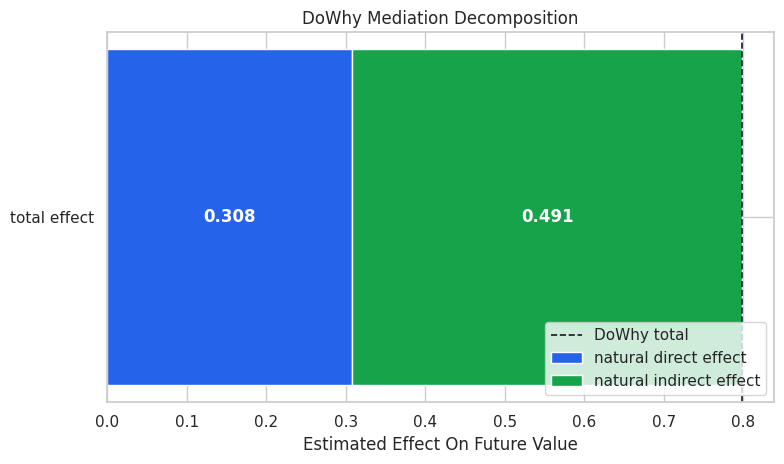

In [20]:
decomp_plot_df = pd.DataFrame(
    [
        {"component": "natural direct effect", "estimate": direct_effect_estimate.value},
        {"component": "natural indirect effect", "estimate": indirect_effect_estimate.value},
    ]
)

fig, ax = plt.subplots(figsize=(8, 4.8))
left = 0
colors = {"natural direct effect": "#2563eb", "natural indirect effect": "#16a34a"}
for _, row in decomp_plot_df.iterrows():
    ax.barh(
        y=["total effect"],
        width=row["estimate"],
        left=left,
        color=colors[row["component"]],
        label=row["component"],
    )
    ax.text(
        left + row["estimate"] / 2,
        0,
        f"{row['estimate']:.3f}",
        ha="center",
        va="center",
        color="white",
        fontweight="bold",
    )
    left += row["estimate"]

ax.axvline(total_effect_estimate.value, color="#111827", linestyle="--", linewidth=1.2, label="DoWhy total")
ax.set_title("DoWhy Mediation Decomposition")
ax.set_xlabel("Estimated Effect On Future Value")
ax.set_ylabel("")
ax.legend(loc="lower right")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "12_mediation_decomposition_bar.png", dpi=160, bbox_inches="tight")
plt.show()

The indirect component is larger than the direct component in this simulation. That means most of the exposure effect is transmitted through satisfaction depth.

## Proportion Mediated

A common summary is the proportion mediated: indirect effect divided by total effect. This is easy to communicate, but it can become unstable when the total effect is small, close to zero, or has components with opposite signs.

In [21]:
proportion_mediated = indirect_effect_estimate.value / total_effect_estimate.value

proportion_summary = pd.DataFrame(
    [
        {
            "quantity": "proportion mediated",
            "estimate": proportion_mediated,
            "numerator": "natural indirect effect",
            "denominator": "total effect",
            "caution": "Use carefully when the total effect is small or signs differ.",
        }
    ]
)

proportion_summary.to_csv(TABLE_DIR / "12_proportion_mediated.csv", index=False)
display(proportion_summary)

,quantity,estimate,numerator,denominator,caution
0,proportion mediated,0.6143,natural indirect effect,total effect,Use carefully when the total effect is small o...


Here the proportion mediated is easy to read because the direct and indirect effects are both positive. In messier applications, this metric should be reported with context rather than as a standalone headline.

## Bootstrap Uncertainty For The Manual Decomposition

DoWhy's two-stage result gives the point estimate. To teach uncertainty around the manual decomposition, we bootstrap rows and recompute the two-stage estimates. This is a simple nonparametric bootstrap, not a cure for violated mediation assumptions.

In [22]:
def fit_manual_mediation(data):
    """Return total, indirect, and direct effects from the manual two-stage regressions."""
    mediator_fit = sm.OLS(
        data["satisfaction_depth"],
        sm.add_constant(data[["discovery_exposure"] + pre_treatment_covariates]),
    ).fit()
    outcome_fit = sm.OLS(
        data["future_value"],
        sm.add_constant(data[["discovery_exposure", "satisfaction_depth"] + pre_treatment_covariates]),
    ).fit()
    total_fit = sm.OLS(
        data["future_value"],
        sm.add_constant(data[["discovery_exposure"] + pre_treatment_covariates]),
    ).fit()
    indirect = mediator_fit.params["discovery_exposure"] * outcome_fit.params["satisfaction_depth"]
    direct = outcome_fit.params["discovery_exposure"]
    total = total_fit.params["discovery_exposure"]
    return total, indirect, direct

bootstrap_rng = np.random.default_rng(RANDOM_SEED + 12)
bootstrap_rows = []
N_BOOT = 250

for draw in range(N_BOOT):
    sample_index = bootstrap_rng.integers(0, len(mediation_df), size=len(mediation_df))
    bootstrap_sample = mediation_df.iloc[sample_index]
    total, indirect, direct = fit_manual_mediation(bootstrap_sample)
    bootstrap_rows.append(
        {
            "draw": draw,
            "total_effect": total,
            "natural_indirect_effect": indirect,
            "natural_direct_effect": direct,
        }
    )

bootstrap_effects = pd.DataFrame(bootstrap_rows)
bootstrap_effects.to_csv(TABLE_DIR / "12_bootstrap_effect_draws.csv", index=False)

bootstrap_summary = (
    bootstrap_effects.drop(columns=["draw"])
    .agg(["mean", "std", lambda x: np.quantile(x, 0.025), lambda x: np.quantile(x, 0.975)])
    .T
    .reset_index(names="quantity")
    .rename(columns={"<lambda_0>": "ci_95_lower", "<lambda_1>": "ci_95_upper"})
)

bootstrap_summary.to_csv(TABLE_DIR / "12_bootstrap_effect_summary.csv", index=False)
display(bootstrap_summary)

,quantity,mean,std,<lambda>,<lambda>
0,total_effect,0.7972,0.0194,0.7614,0.8327
1,natural_indirect_effect,0.4894,0.0146,0.4613,0.5198
2,natural_direct_effect,0.3078,0.0187,0.2716,0.3442


The bootstrap intervals are narrow because the sample is large and the data-generating process matches the estimator. In real mediation work, uncertainty from model choice and graph assumptions is often larger than bootstrap sampling uncertainty.

## Plot Bootstrap Distributions

The bootstrap distributions show sampling variability around each component. This is useful for reporting because direct and indirect components can have different precision.

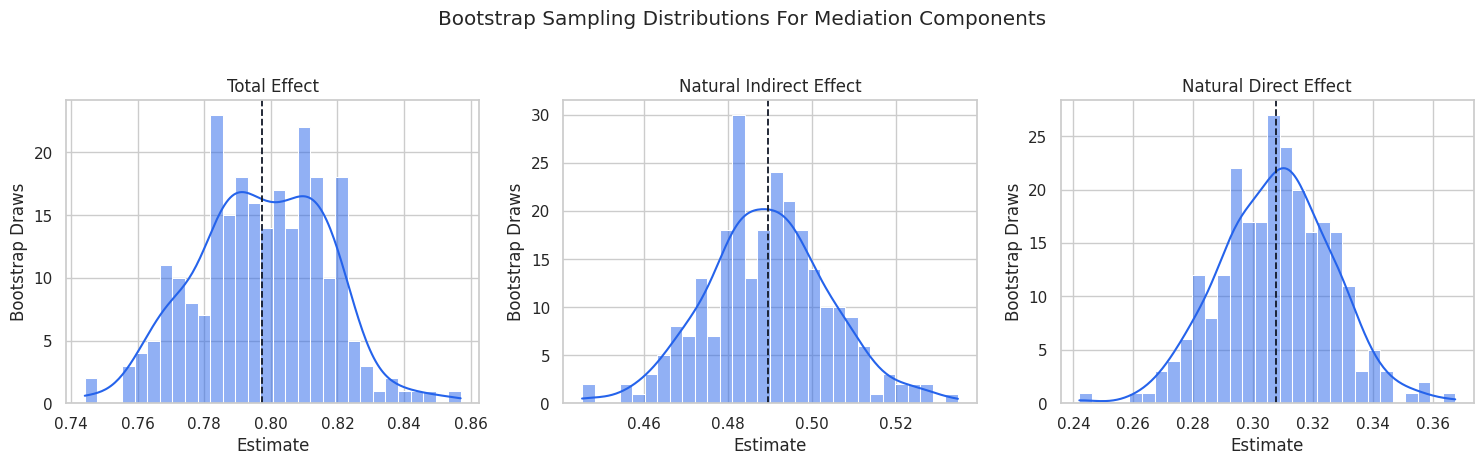

In [23]:
bootstrap_plot_df = bootstrap_effects.melt(
    id_vars="draw",
    var_name="quantity",
    value_name="estimate",
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=False)
for ax, quantity in zip(axes, ["total_effect", "natural_indirect_effect", "natural_direct_effect"]):
    subset = bootstrap_plot_df[bootstrap_plot_df["quantity"] == quantity]
    sns.histplot(subset, x="estimate", bins=30, kde=True, color="#2563eb", ax=ax)
    ax.axvline(subset["estimate"].mean(), color="#111827", linestyle="--", linewidth=1.3)
    ax.set_title(quantity.replace("_", " ").title())
    ax.set_xlabel("Estimate")
    ax.set_ylabel("Bootstrap Draws")

fig.suptitle("Bootstrap Sampling Distributions For Mediation Components", y=1.03)
plt.tight_layout()
fig.savefig(FIGURE_DIR / "12_bootstrap_mediation_distributions.png", dpi=160, bbox_inches="tight")
plt.show()

The bootstrap draws are centered near the point estimates. The direct effect is the smallest component here, but it is still clearly positive in this teaching setup.

## Why The Mediator Is A Bad Control For Total Effects

A common mistake is to estimate a total effect while controlling for the mediator. That blocks the indirect path and changes the question from total effect to a direct-effect-like contrast.

The next cell compares three regression specifications to make this concrete.

In [24]:
naive_total_model = sm.OLS(
    mediation_df["future_value"],
    sm.add_constant(mediation_df[["discovery_exposure"]]),
).fit()

adjusted_total_model = sm.OLS(
    mediation_df["future_value"],
    sm.add_constant(mediation_df[["discovery_exposure"] + pre_treatment_covariates]),
).fit()

bad_control_model = sm.OLS(
    mediation_df["future_value"],
    sm.add_constant(mediation_df[["discovery_exposure", "satisfaction_depth"] + pre_treatment_covariates]),
).fit()

bad_control_comparison = pd.DataFrame(
    [
        {
            "model": "naive outcome ~ treatment",
            "treatment_coefficient": naive_total_model.params["discovery_exposure"],
            "what it estimates": "confounded association",
            "why it differs": "does not adjust for pre-treatment selection",
        },
        {
            "model": "outcome ~ treatment + pre-treatment covariates",
            "treatment_coefficient": adjusted_total_model.params["discovery_exposure"],
            "what it estimates": "adjusted total effect",
            "why it differs": "allows mediator pathway to remain open",
        },
        {
            "model": "outcome ~ treatment + mediator + pre-treatment covariates",
            "treatment_coefficient": bad_control_model.params["discovery_exposure"],
            "what it estimates": "direct-effect-like coefficient",
            "why it differs": "blocks the mediator pathway",
        },
    ]
)

bad_control_comparison.to_csv(TABLE_DIR / "12_bad_control_comparison.csv", index=False)
display(bad_control_comparison)

,model,treatment_coefficient,what it estimates,why it differs
0,naive outcome ~ treatment,1.5689,confounded association,does not adjust for pre-treatment selection
1,outcome ~ treatment + pre-treatment covariates,0.7986,adjusted total effect,allows mediator pathway to remain open
2,outcome ~ treatment + mediator + pre-treatment...,0.3080,direct-effect-like coefficient,blocks the mediator pathway


The mediator-adjusted coefficient is much smaller than the adjusted total effect because it removes the indirect path. That is correct for a direct-effect question, but wrong if the target is the total effect.

## Plot The Bad-Control Lesson

The same comparison is often clearer as a plot. The important gap is between the adjusted total-effect model and the mediator-adjusted model.

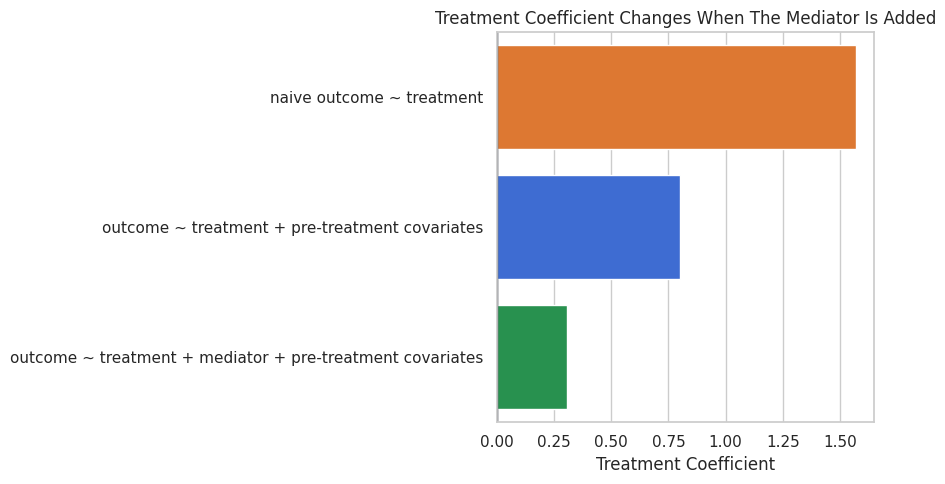

In [25]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=bad_control_comparison,
    x="treatment_coefficient",
    y="model",
    hue="model",
    dodge=False,
    palette=["#f97316", "#2563eb", "#16a34a"],
    legend=False,
    ax=ax,
)
ax.axvline(0, color="#111827", linewidth=1)
ax.set_title("Treatment Coefficient Changes When The Mediator Is Added")
ax.set_xlabel("Treatment Coefficient")
ax.set_ylabel("")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "12_bad_control_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

The plot shows why adjustment sets must follow the estimand. Pre-treatment covariates are adjustment variables for the total effect; the mediator is not.

## Controlled Direct Effects

A controlled direct effect asks what the treatment effect would be if the mediator were fixed to a chosen value for everyone. This is different from the natural direct effect, where the mediator is held to a natural reference-world value.

We estimate controlled direct effects with the fitted outcome regression by predicting outcomes under treatment and control while setting `satisfaction_depth` to selected quantiles.

In [26]:
mediator_values = mediation_df["satisfaction_depth"].quantile([0.10, 0.50, 0.90]).rename("fixed_mediator_value")
controlled_direct_rows = []

base_covariates = mediation_df[pre_treatment_covariates].copy()

for quantile, fixed_mediator_value in mediator_values.items():
    treated_design = pd.DataFrame(
        {
            "const": 1.0,
            "discovery_exposure": 1,
            "satisfaction_depth": fixed_mediator_value,
            "baseline_need": base_covariates["baseline_need"],
            "prior_activity": base_covariates["prior_activity"],
            "account_tenure": base_covariates["account_tenure"],
        }
    )
    control_design = treated_design.copy()
    control_design["discovery_exposure"] = 0

    treated_prediction = outcome_model.predict(treated_design)
    control_prediction = outcome_model.predict(control_design)

    controlled_direct_rows.append(
        {
            "mediator_quantile": quantile,
            "fixed_mediator_value": fixed_mediator_value,
            "controlled_direct_effect": float((treated_prediction - control_prediction).mean()),
        }
    )

controlled_direct_effects = pd.DataFrame(controlled_direct_rows)
controlled_direct_effects.to_csv(TABLE_DIR / "12_controlled_direct_effects.csv", index=False)
display(controlled_direct_effects)

,mediator_quantile,fixed_mediator_value,controlled_direct_effect
0,0.1000,-1.0545,0.3080
1,0.5000,0.2816,0.3080
2,0.9000,1.6615,0.3080


The controlled direct effect is nearly constant across mediator values because the simulated outcome equation has no treatment-by-mediator interaction. If the outcome model included that interaction, the controlled direct effect could vary by mediator level.

## Visualize Controlled Direct Effects

This plot highlights whether fixing the mediator at different values changes the direct effect. In this simple teaching system, the line is nearly flat.

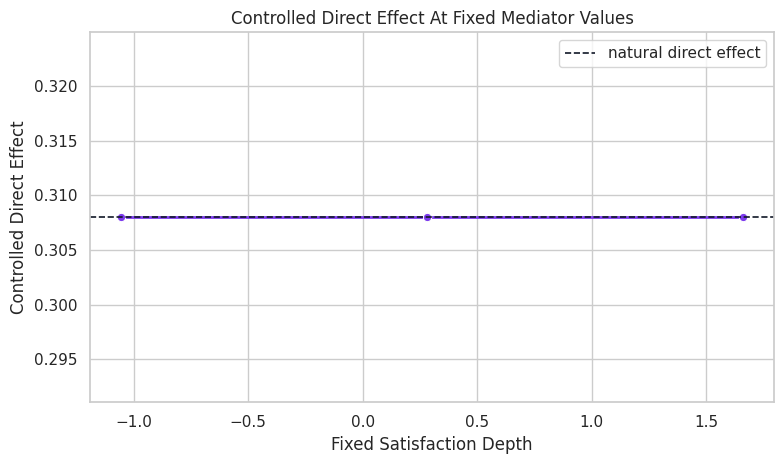

In [27]:
fig, ax = plt.subplots(figsize=(8, 4.8))
sns.lineplot(
    data=controlled_direct_effects,
    x="fixed_mediator_value",
    y="controlled_direct_effect",
    marker="o",
    linewidth=2,
    color="#7c3aed",
    ax=ax,
)
ax.axhline(direct_effect_estimate.value, color="#111827", linestyle="--", linewidth=1.2, label="natural direct effect")
ax.set_title("Controlled Direct Effect At Fixed Mediator Values")
ax.set_xlabel("Fixed Satisfaction Depth")
ax.set_ylabel("Controlled Direct Effect")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURE_DIR / "12_controlled_direct_effects.png", dpi=160, bbox_inches="tight")
plt.show()

The controlled direct effect and natural direct effect are close here because the structural system is simple. In richer systems, they answer different hypothetical questions and should not be used interchangeably.

## Mediation Assumption Register

Mediation requires more assumptions than a total-effect analysis. The table below lists the assumptions this notebook relies on and what can go wrong when they fail.

In [28]:
assumption_register = pd.DataFrame(
    [
        {
            "assumption": "Correct causal ordering",
            "meaning": "Treatment occurs before mediator; mediator occurs before outcome.",
            "risk if violated": "A post-outcome variable may be mislabeled as a mediator.",
        },
        {
            "assumption": "No unmeasured treatment-outcome confounding",
            "meaning": "Pre-treatment covariates block backdoor paths from treatment to outcome.",
            "risk if violated": "Total and direct effects can be biased.",
        },
        {
            "assumption": "No unmeasured treatment-mediator confounding",
            "meaning": "Pre-treatment covariates block backdoor paths from treatment to mediator.",
            "risk if violated": "The first-stage treatment-to-mediator relationship can be biased.",
        },
        {
            "assumption": "No unmeasured mediator-outcome confounding",
            "meaning": "After treatment and pre-treatment covariates, mediator-outcome confounding is blocked.",
            "risk if violated": "The mediator-to-outcome coefficient can be biased.",
        },
        {
            "assumption": "No treatment-induced mediator-outcome confounder",
            "meaning": "Treatment does not create a new variable that confounds mediator and outcome.",
            "risk if violated": "Natural direct and indirect effects may not be identified by the simple design.",
        },
        {
            "assumption": "Model form is adequate",
            "meaning": "The regression models capture the relevant relationships.",
            "risk if violated": "The product-of-coefficients decomposition can be numerically misleading.",
        },
    ]
)

assumption_register.to_csv(TABLE_DIR / "12_mediation_assumption_register.csv", index=False)
display(assumption_register)

,assumption,meaning,risk if violated
0,Correct causal ordering,Treatment occurs before mediator; mediator occ...,A post-outcome variable may be mislabeled as a...
1,No unmeasured treatment-outcome confounding,Pre-treatment covariates block backdoor paths ...,Total and direct effects can be biased.
2,No unmeasured treatment-mediator confounding,Pre-treatment covariates block backdoor paths ...,The first-stage treatment-to-mediator relation...
3,No unmeasured mediator-outcome confounding,"After treatment and pre-treatment covariates, ...",The mediator-to-outcome coefficient can be bia...
4,No treatment-induced mediator-outcome confounder,Treatment does not create a new variable that ...,Natural direct and indirect effects may not be...
5,Model form is adequate,The regression models capture the relevant rel...,The product-of-coefficients decomposition can ...


The mediator-outcome confounding assumption is often the hardest one. A mediator is not randomized in most observational data, so there may be unobserved reasons why the mediator and outcome move together.

## Sensitivity Thought Experiment: Omitted Mediator-Outcome Confounding

To see the risk, we create a second dataset where an unobserved factor affects both the mediator and outcome. We deliberately omit that factor from the analysis, then rerun the same manual mediation decomposition.

In [29]:
latent_affinity = rng.normal(0, 1, size=N)

confounded_mediator = (
    0.65 * discovery_exposure
    + 0.55 * baseline_need
    + 0.30 * prior_activity
    - 0.20 * account_tenure
    + 0.55 * latent_affinity
    + rng.normal(0, 0.65, size=N)
)

confounded_outcome = (
    0.30 * discovery_exposure
    + 0.75 * confounded_mediator
    + 0.45 * baseline_need
    + 0.25 * prior_activity
    - 0.15 * account_tenure
    + 0.60 * latent_affinity
    + rng.normal(0, 0.70, size=N)
)

confounded_df = mediation_df.copy()
confounded_df["satisfaction_depth"] = confounded_mediator
confounded_df["future_value"] = confounded_outcome
confounded_df["latent_affinity"] = latent_affinity

# Analyst view: omit latent_affinity, because in real data it would be unobserved.
analyst_view = confounded_df.drop(columns=["latent_affinity"])
confounded_total, confounded_indirect, confounded_direct = fit_manual_mediation(analyst_view)

# Oracle view: include latent_affinity to show the direction of the omitted-confounder bias.
def fit_manual_mediation_with_latent(data):
    covariates = pre_treatment_covariates + ["latent_affinity"]
    mediator_fit = sm.OLS(
        data["satisfaction_depth"],
        sm.add_constant(data[["discovery_exposure"] + covariates]),
    ).fit()
    outcome_fit = sm.OLS(
        data["future_value"],
        sm.add_constant(data[["discovery_exposure", "satisfaction_depth"] + covariates]),
    ).fit()
    total_fit = sm.OLS(
        data["future_value"],
        sm.add_constant(data[["discovery_exposure"] + covariates]),
    ).fit()
    indirect = mediator_fit.params["discovery_exposure"] * outcome_fit.params["satisfaction_depth"]
    direct = outcome_fit.params["discovery_exposure"]
    total = total_fit.params["discovery_exposure"]
    return total, indirect, direct

oracle_total, oracle_indirect, oracle_direct = fit_manual_mediation_with_latent(confounded_df)

omitted_confounder_comparison = pd.DataFrame(
    [
        {
            "analysis": "original clean teaching data",
            "total_effect": manual_total,
            "natural_indirect_effect": manual_indirect,
            "natural_direct_effect": manual_direct,
        },
        {
            "analysis": "confounded data, latent factor omitted",
            "total_effect": confounded_total,
            "natural_indirect_effect": confounded_indirect,
            "natural_direct_effect": confounded_direct,
        },
        {
            "analysis": "confounded data, latent factor observed as oracle",
            "total_effect": oracle_total,
            "natural_indirect_effect": oracle_indirect,
            "natural_direct_effect": oracle_direct,
        },
    ]
)

omitted_confounder_comparison.to_csv(TABLE_DIR / "12_omitted_mediator_outcome_confounder.csv", index=False)
display(omitted_confounder_comparison)

,analysis,total_effect,natural_indirect_effect,natural_direct_effect
0,original clean teaching data,0.7986,0.4906,0.3080
1,"confounded data, latent factor omitted",0.7374,0.7766,-0.0392
2,"confounded data, latent factor observed as oracle",0.7788,0.4993,0.2795


When the latent mediator-outcome confounder is omitted, the indirect effect is distorted. The oracle row shows that observing the latent factor would recover a more credible decomposition.

## Plot The Omitted-Confounder Stress Test

The plot below focuses on how the direct and indirect components change under omitted mediator-outcome confounding.

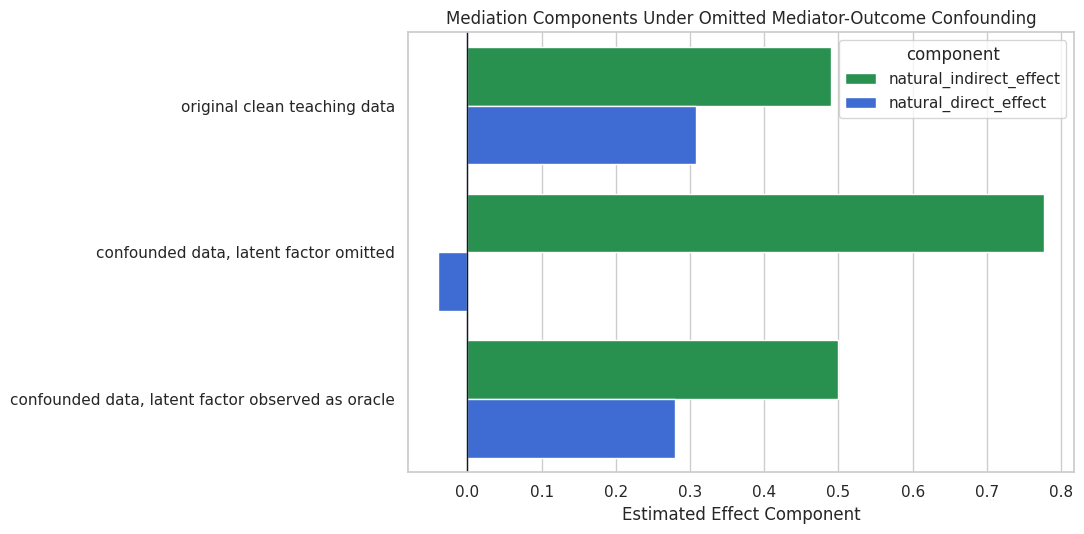

In [30]:
stress_plot_df = omitted_confounder_comparison.melt(
    id_vars="analysis",
    value_vars=["natural_indirect_effect", "natural_direct_effect"],
    var_name="component",
    value_name="estimate",
)

fig, ax = plt.subplots(figsize=(11, 5.5))
sns.barplot(
    data=stress_plot_df,
    x="estimate",
    y="analysis",
    hue="component",
    palette=["#16a34a", "#2563eb"],
    ax=ax,
)
ax.axvline(0, color="#111827", linewidth=1)
ax.set_title("Mediation Components Under Omitted Mediator-Outcome Confounding")
ax.set_xlabel("Estimated Effect Component")
ax.set_ylabel("")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "12_omitted_mediator_outcome_confounder.png", dpi=160, bbox_inches="tight")
plt.show()

The omitted-confounder case is the cautionary heart of mediation analysis. Even if the total effect is reasonably estimated, the pathway split can be wrong when the mediator-outcome relationship is confounded.

## Reporting Template

A mediation result should not be reported as just one table of coefficients. It should include the graph, timing, estimands, estimator, assumptions, and sensitivity concerns.

In [31]:
reporting_template = pd.DataFrame(
    [
        {
            "report section": "Causal question",
            "what to include": "State the treatment, mediator, outcome, and target population.",
            "example from notebook": "How much of exposure's effect on future value flows through satisfaction depth?",
        },
        {
            "report section": "Temporal ordering",
            "what to include": "Document when treatment, mediator, outcome, and covariates are measured.",
            "example from notebook": "Covariates before exposure; mediator after exposure; outcome later.",
        },
        {
            "report section": "Graph assumptions",
            "what to include": "Show the DAG and identify pre-treatment confounders.",
            "example from notebook": "Baseline need, prior activity, and tenure affect treatment, mediator, and outcome.",
        },
        {
            "report section": "Effect decomposition",
            "what to include": "Report total, direct, indirect, and proportion mediated where appropriate.",
            "example from notebook": "Direct plus indirect approximately equals total in the linear setup.",
        },
        {
            "report section": "Sensitivity and limitations",
            "what to include": "Discuss mediator-outcome confounding and treatment-induced confounders.",
            "example from notebook": "The latent-confounder stress test shows pathway estimates can move substantially.",
        },
    ]
)

reporting_template.to_csv(TABLE_DIR / "12_reporting_template.csv", index=False)
display(reporting_template)

,report section,what to include,example from notebook
0,Causal question,"State the treatment, mediator, outcome, and ta...",How much of exposure's effect on future value ...
1,Temporal ordering,"Document when treatment, mediator, outcome, an...",Covariates before exposure; mediator after exp...
2,Graph assumptions,Show the DAG and identify pre-treatment confou...,"Baseline need, prior activity, and tenure affe..."
3,Effect decomposition,"Report total, direct, indirect, and proportion...",Direct plus indirect approximately equals tota...
4,Sensitivity and limitations,Discuss mediator-outcome confounding and treat...,The latent-confounder stress test shows pathwa...


The template keeps the analysis honest. Mediation can be very compelling narratively, so the assumptions should be placed next to the estimates rather than hidden in a footnote.

## Final Summary

This notebook decomposed a treatment effect into direct and indirect pathways with DoWhy and a transparent manual calculation.

Key takeaways:

- The total effect allows the mediator to change naturally.
- The natural indirect effect captures the part of the effect transmitted through the mediator.
- The natural direct effect captures the remaining pathway outside the mediator.
- Adjusting for the mediator changes the estimand; it is not a valid total-effect adjustment.
- Mediation analysis depends heavily on mediator timing and no unmeasured mediator-outcome confounding.
- The product-of-coefficients approach is easy to explain in a linear setting, but its assumptions should be stated plainly.

The next tutorial moves into GCM tools for root-cause analysis, anomaly attribution, and distribution-change attribution.